# Selective PDF-recommendation notebook + Kira feedback + final safe supervised-learning improvement

This notebook keeps the selected data-validity fixes and Kira feedback integration, then adds a more defensible supervised-learning improvement attempt:

- multiple PM lag features and rolling lag summaries;
- cyclic hour/month features;
- wind-speed × wind-direction interactions;
- city/season fixed-effect dummies for fairer city-level comparison;
- Random Forest tuning on **2014 validation only**;
- final untouched holdout evaluation on **2015**;
- optional delta-PM model predicting deviations from lag-1 persistence;
- city-month block bootstrap uncertainty for the final test metrics.

The purpose is to test whether performance can improve without overfitting to the 2015 test year.


## Final safe improvement extension
This version adds one last defensible supervised-learning extension while keeping the 2015 holdout untouched: lagged weather variables, PM trend/difference features, and a validation-tuned histogram gradient boosting model. Hyperparameters are selected using 2014 only; 2015 remains the final chronological test.


In [5]:
# =============================================================================
# STEP 1 — Data Ingestion & Cleaning
# Owner: Danish
# Dataset: PM2.5 Data of Five Chinese Cities (UCI ML Repository)
# Coverage: hourly observations, 2010-01-01 → 2015-12-31
#
# Selective PDF-recommendation version
# ─────────────────────────────────────────────────────────────────────────────
# Incorporated here:
#   1) Do NOT treat missing precipitation as "dry hour" / 0.0.
#      Precipitation is retained for diagnostics but excluded from the main model.
#   2) Avoid unlimited PM target imputation. Only one-hour PM gaps are forward-filled.
#      Remaining missing PM rows are dropped.
#   3) Preserve circular wind direction via wind_sin and wind_cos, when cbwd exists.
#
# Deliberately NOT changed here:
#   • PM station columns are still averaged to city-hour PM for comparability with
#     the original notebook. A station-level refactor is better as a separate
#     robustness/extension notebook because it changes the unit of analysis.
# =============================================================================

import os
import pandas as pd
import numpy as np

# ── 1. File map ───────────────────────────────────────────────────────────────
# Place the five raw CSVs in the same directory as this notebook.
FILE_MAP = {
    "Beijing":   "BeijingPM20100101_20151231.csv",
    "Shanghai":  "ShanghaiPM20100101_20151231.csv",
    "Guangzhou": "GuangzhouPM20100101_20151231.csv",
    "Chengdu":   "ChengduPM20100101_20151231.csv",
    "Shenyang":  "ShenyangPM20100101_20151231.csv",
}

# Structural columns shared across all five datasets.
# cbwd = combined wind direction, used to create wind_sin/wind_cos.
# precipitation is retained only for diagnostics because it is absent / missing in
# some city files and should NOT be imputed to 0.0.
CORE_COLS = ["city", "year", "month", "day", "hour", "season",
             "PM", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "cbwd", "precipitation"]

# Main model features available immediately after Step 1.
# Precipitation is intentionally excluded from the main model. If you later add
# reliable precipitation data for all cities, add it back as a robustness model.
WEATHER_FEATURES = ["TEMP", "PRES", "HUMI", "DEWP", "Iws"]
WIND_FEATURES = ["wind_sin", "wind_cos", "wind_dir_missing"]

# ── 2. Heating-regime definition ──────────────────────────────────────────────
# Treatment variable (causal block): binary indicator that equals 1 when
# the city is inside the government-mandated northern heating zone AND the
# calendar month falls within the active heating season (November–March).

HEATING_CITIES  = {"Beijing", "Shenyang"}
HEATING_MONTHS  = {11, 12, 1, 2, 3}          # Nov–Mar (inclusive)

def engineer_heating_regime(df: pd.DataFrame) -> pd.DataFrame:
    """Add binary `heating_regime` column (treatment variable for causal block)."""
    df = df.copy()
    df["heating_regime"] = (
        df["city"].isin(HEATING_CITIES) & df["month"].isin(HEATING_MONTHS)
    ).astype(int)
    return df

# ── 3. Wind-direction encoding ────────────────────────────────────────────────
# Meteorological convention: North = 0°, East = 90°, South = 180°, West = 270°.
# The UCI files often contain cbwd values such as NE, NW, SE, SW and sometimes
# "cv" (calm/variable). Calm/variable has undefined direction, so we encode both
# sin/cos as 0 and set wind_dir_missing = 1.

WIND_ANGLE_MAP = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}
CALM_OR_VARIABLE = {"CV", "CALM", "VARIABLE", "VAR", "NONE", ""}

def add_wind_direction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Encode cbwd as circular wind_sin/wind_cos plus an undefined-direction flag."""
    df = df.copy()

    if "cbwd" not in df.columns:
        df["cbwd"] = np.nan

    cbwd = df["cbwd"].astype("string").str.strip().str.upper()
    angle = cbwd.map(WIND_ANGLE_MAP).astype(float)

    calm_or_variable = cbwd.isin(CALM_OR_VARIABLE)
    unmapped_or_missing = cbwd.isna() | (angle.isna() & ~calm_or_variable)
    undefined_direction = calm_or_variable | unmapped_or_missing

    theta = np.deg2rad(angle)
    df["wind_sin"] = np.sin(theta)
    df["wind_cos"] = np.cos(theta)

    # Undefined direction: no meaningful direction vector; set vector to zero
    # and let wind_dir_missing tell the model that direction was unavailable.
    df.loc[undefined_direction, ["wind_sin", "wind_cos"]] = 0.0
    df["wind_dir_missing"] = undefined_direction.astype(int)
    df["wind_angle"] = angle

    return df

# ── 4. Ingestion loop ─────────────────────────────────────────────────────────

def load_city(city: str, filename: str) -> pd.DataFrame:
    """
    Read one city CSV and return a cleaned slice with unified columns.

    Key operations
    ──────────────
    • Detect and average across PM_* monitoring-station columns → city-hour `PM`.
      This keeps comparability with the original notebook. Station-level analysis
      should be tested separately because it changes the unit of analysis.
    • Retain cbwd for circular wind encoding.
    • Keep precipitation as missing where missing; do NOT fill missing values with 0.
    • Attach `city` label for panel identification.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Expected '{filename}' in the working directory. "
            "Download all five CSVs from https://archive-beta.ics.uci.edu/dataset/394"
        )

    df = pd.read_csv(filename, na_values=["NA", "NaN", " ", ""])
    df["city"] = city

    # Consolidate station-level PM columns into one city-hour target.
    # This is intentionally left as-is for this comparison notebook.
    pm_cols = [c for c in df.columns if c.upper().startswith("PM_")]
    if not pm_cols:
        raise ValueError(f"No PM_* columns found in {filename}. Check column names.")
    df["PM"] = df[pm_cols].mean(axis=1)

    # Add optional columns as NaN if absent so all city frames align.
    for optional_col in ["cbwd", "precipitation"]:
        if optional_col not in df.columns:
            df[optional_col] = np.nan

    available = [c for c in CORE_COLS if c in df.columns]
    df = df[available].copy()
    return df


print("── Ingesting city datasets ──────────────────────────────────────────────")
city_frames = []
for city, filename in FILE_MAP.items():
    frame = load_city(city, filename)
    print(f"  {city:10s}  {len(frame):>7,} raw rows  |  PM cols averaged")
    city_frames.append(frame)

df_raw = pd.concat(city_frames, ignore_index=True)
print(f"\n  Combined (raw):  {len(df_raw):>7,} rows × {df_raw.shape[1]} columns")

# ── 5. Temporal ordering ──────────────────────────────────────────────────────
# Sort the full panel chronologically within each city so that forward-fill
# operates strictly along the time axis.

df_raw = (df_raw
          .sort_values(["city", "year", "month", "day", "hour"])
          .reset_index(drop=True))

# =============================================================================
# Sensor anomaly handling: convert hidden -9999.0 error codes to NaN.
# =============================================================================
print("── Processing data quality check: Purging -9999 sensor faults ──────────")
for col in ["HUMI", "DEWP"]:
    if col in df_raw.columns:
        fault_count = (df_raw[col] == -9999.0).sum()
        print(f"  Found {fault_count:,} sensor error records (-9999.0) in column: {col}")
        df_raw[col] = df_raw[col].replace(-9999.0, np.nan)
print("  Purge successful. Anomalies converted to NaN placeholders.\n")

# Capture true raw missingness before PM forward-fill and row dropping.
missing_diagnostic_cols = ["PM"] + WEATHER_FEATURES + ["cbwd", "precipitation"]
raw_missing_before_handling = (
    df_raw.groupby("city", observed=True)[missing_diagnostic_cols]
    .apply(lambda g: g.isna().sum())
)
precip_nulls_by_city = df_raw.groupby("city", observed=True)["precipitation"].apply(lambda g: g.isna().sum())

# ── 6. Missing-value handling ─────────────────────────────────────────────────
# Selective PDF-response strategy:
#   (a) PM target: allow only one-hour forward fill within each city. This avoids
#       turning long monitor outages into artificial flat PM periods.
#   (b) Weather features: drop rows with missing core weather values.
#   (c) Precipitation: do not impute as zero. Keep for diagnostics, but exclude
#       it from the main model.

print("── Missing-value strategy ───────────────────────────────────────────────")
print("  PM target       : forward-fill within city with limit=1 hour only")
print("  Weather features: drop rows with missing TEMP/PRES/HUMI/DEWP/Iws")
print("  Precipitation   : keep missing as NaN; excluded from main model")

pm_nulls_before = df_raw["PM"].isna().sum()
df_raw["PM"] = df_raw.groupby("city", observed=True)["PM"].ffill(limit=1)
pm_nulls_after = df_raw["PM"].isna().sum()
print(f"  PM missing before limited ffill : {pm_nulls_before:,}")
print(f"  PM missing after limited ffill  : {pm_nulls_after:,}")

# Wind direction is added before dropna so all downstream steps can use it.
df_raw = add_wind_direction_features(df_raw)

wind_undefined_by_city = df_raw.groupby("city", observed=True)["wind_dir_missing"].sum()
print("\n── Wind-direction encoding ──────────────────────────────────────────────")
print("  Created wind_sin, wind_cos, and wind_dir_missing from cbwd")
print("  Undefined/calm/variable/missing wind-direction rows by city:")
print(wind_undefined_by_city.to_string())

# Drop rows where model-critical fields remain missing. Precipitation is not in
# this subset because it is not used in the main model.
n_before_drop = len(df_raw)
CRITICAL_MODEL_COLS = ["PM"] + WEATHER_FEATURES + WIND_FEATURES

df_clean = df_raw.dropna(subset=CRITICAL_MODEL_COLS).reset_index(drop=True)
n_dropped = n_before_drop - len(df_clean)
print(f"\n  Rows dropped (PM/weather/wind critical nulls): {n_dropped:,}")
print(f"  Rows retained (clean panel)                 : {len(df_clean):,}")

# ── 7. Treatment variable engineering ────────────────────────────────────────
df_clean = engineer_heating_regime(df_clean)

regime_counts = df_clean.groupby("city", observed=True)["heating_regime"].sum()
print(f"\n── heating_regime summary (treated hours per city) ─────────────────────")
print(regime_counts.to_string())

# ── 8. Data-type enforcement ──────────────────────────────────────────────────
# Categorical city saves memory and speeds groupby operations downstream.
df_clean["city"]    = df_clean["city"].astype("category")
df_clean["season"]  = df_clean["season"].astype("category")

# Ensure temporal integers are native int (not float from merge artefacts)
for col in ["year", "month", "day", "hour"]:
    df_clean[col] = df_clean[col].astype(int)

# ── 9. Sanity checks ──────────────────────────────────────────────────────────
print("\n── Sanity checks ────────────────────────────────────────────────────────")

# (i) Year coverage
print(f"  Year range  : {df_clean['year'].min()} – {df_clean['year'].max()}")

# (ii) No remaining nulls in model-critical columns
null_summary = df_clean[CRITICAL_MODEL_COLS + ["heating_regime"]].isnull().sum()
assert null_summary.sum() == 0, f"Unexpected nulls remaining:\n{null_summary[null_summary > 0]}"
print("  Null check  : PASSED — no missing values in critical model columns")

# (iii) Precipitation may still contain NaNs by design
precip_missing_clean = df_clean["precipitation"].isna().sum()
print(f"  Precip NaNs : {precip_missing_clean:,} retained by design; not used in main model")

# (iv) heating_regime is strictly binary
assert set(df_clean["heating_regime"].unique()).issubset({0, 1}), "heating_regime contains non-binary values"
print("  Binary check: PASSED — heating_regime ∈ {0, 1}")

# (v) All five cities present
assert set(df_clean["city"].cat.categories) == set(FILE_MAP.keys()), "Missing cities in clean panel"
print(f"  Cities      : {sorted(df_clean['city'].cat.categories.tolist())}")

# (vi) PM values are non-negative (physical constraint)
assert (df_clean["PM"] >= 0).all(), "Negative PM2.5 values detected — check source data"
print(f"  PM range    : {df_clean['PM'].min():.1f} – {df_clean['PM'].max():.1f} µg/m³")

# ── 10. Final overview ────────────────────────────────────────────────────────
print("\n── Final dataset ────────────────────────────────────────────────────────")
print(f"  Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Memory : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

display(df_clean.head())
print("\n── Column dtypes & null counts ──────────────────────────────────────────")
df_clean.info()

print("\n── Descriptive statistics ───────────────────────────────────────────────")
display(df_clean.describe())

# =============================================================================
# STEP 1b — Pre-cleaning diagnostics (raw missingness, coverage, range checks)
# =============================================================================

print("── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────")
display(raw_missing_before_handling)
print(f"\n  Total raw rows                 : {len(df_raw):,}")
print(f"  Total rows dropped (Step 1)    : {n_dropped:,} "
      f"({n_dropped / len(df_raw):.2%})")

# ── Precipitation coverage by city ───────────────────────────────────────────
print("\n── Precipitation coverage by city ──────────────────────────────────────")
print("  Missing counts are retained as true missingness; no zero imputation applied.")
print(precip_nulls_by_city.to_string())

# ── Range / sanity checks on weather features (sensor-fault detection) ──────
print("\n── Weather feature range checks (post-clean) ───────────────────────────")
range_checks = df_clean[WEATHER_FEATURES + WIND_FEATURES].agg(["min", "max", "mean", "std"]).round(2)
display(range_checks)

# Flag physically implausible values
implausible = {
    "TEMP": ((df_clean["TEMP"] < -40) | (df_clean["TEMP"] > 50)).sum(),
    "PRES": ((df_clean["PRES"] < 850) | (df_clean["PRES"] > 1100)).sum(),
    "HUMI": ((df_clean["HUMI"] < 0) | (df_clean["HUMI"] > 100)).sum(),
    "Iws":  (df_clean["Iws"] < 0).sum(),
}
print("\n  Implausible-value counts (flagged, not removed):")
for k, v in implausible.items():
    print(f"    {k:6s}: {v}")

# ── Season consistency check ─────────────────────────────────────────────────
print("\n── Season label consistency ─────────────────────────────────────────────")
season_month_map = df_clean.groupby("season", observed=True)["month"].unique()
display(season_month_map.to_frame())

# ── 11. Export clean panel ───────────────────────────────────────────────────
# `df_clean` is the master panel carried forward into all subsequent blocks.
# Steps 2 (EDA), 3 (Causal), 4 (Supervised), and 5 (Unsupervised) all import it.
print("\n✓ Step 1 complete. Use `df_clean` in all downstream steps.")
print("  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,")
print("  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.")


── Ingesting city datasets ──────────────────────────────────────────────
  Beijing      52,584 raw rows  |  PM cols averaged
  Shanghai     52,584 raw rows  |  PM cols averaged
  Guangzhou    52,584 raw rows  |  PM cols averaged
  Chengdu      52,584 raw rows  |  PM cols averaged
  Shenyang     52,584 raw rows  |  PM cols averaged

  Combined (raw):  262,920 rows × 14 columns
── Processing data quality check: Purging -9999 sensor faults ──────────
  Found 4 sensor error records (-9999.0) in column: HUMI
  Found 4 sensor error records (-9999.0) in column: DEWP
  Purge successful. Anomalies converted to NaN placeholders.

── Missing-value strategy ───────────────────────────────────────────────
  PM target       : forward-fill within city with limit=1 hour only
  Weather features: drop rows with missing TEMP/PRES/HUMI/DEWP/Iws
  Precipitation   : keep missing as NaN; excluded from main model
  PM missing before limited ffill : 87,675
  PM missing after limited ffill  : 86,927

── Wind-d

,city,year,month,day,hour,season,PM,TEMP,PRES,HUMI,DEWP,Iws,cbwd,precipitation,wind_sin,wind_cos,wind_dir_missing,wind_angle,heating_regime
0,Beijing,2010,1,1,23,4.0,129.0,-5.0,1020.0,41.0,-17.0,0.89,cv,0.0,0.000000,0.000000,1,NaN,1
1,Beijing,2010,1,2,0,4.0,148.0,-4.0,1020.0,38.0,-16.0,1.79,SE,0.0,0.707107,-0.707107,0,135.0,1
2,Beijing,2010,1,2,1,4.0,159.0,-4.0,1020.0,42.0,-15.0,2.68,SE,0.0,0.707107,-0.707107,0,135.0,1
3,Beijing,2010,1,2,2,4.0,181.0,-5.0,1021.0,63.5,-11.0,3.57,SE,0.0,0.707107,-0.707107,0,135.0,1
4,Beijing,2010,1,2,3,4.0,138.0,-5.0,1022.0,85.0,-7.0,5.36,SE,0.0,0.707107,-0.707107,0,135.0,1



── Column dtypes & null counts ──────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 175119 entries, 0 to 175118
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   city              175119 non-null  category
 1   year              175119 non-null  int64   
 2   month             175119 non-null  int64   
 3   day               175119 non-null  int64   
 4   hour              175119 non-null  int64   
 5   season            175119 non-null  category
 6   PM                175119 non-null  float64 
 7   TEMP              175119 non-null  float64 
 8   PRES              175119 non-null  float64 
 9   HUMI              175119 non-null  float64 
 10  DEWP              175119 non-null  float64 
 11  Iws               175119 non-null  float64 
 12  cbwd              175119 non-null  str     
 13  precipitation     169675 non-null  float64 
 14  wind_sin          175119 non-null  f

,year,month,day,hour,PM,TEMP,PRES,HUMI,DEWP,Iws,precipitation,wind_sin,wind_cos,wind_dir_missing,wind_angle,heating_regime
count,175119.000000,175119.000000,175119.000000,175119.000000,175119.000000,175119.000000,175119.000000,175119.000000,175119.000000,175119.000000,169675.000000,175119.000000,175119.000000,175119.000000,146122.000000,175119.000000
mean,2013.343452,6.661579,15.796338,11.504474,73.553654,15.894195,1013.674762,66.236681,8.601191,22.032507,0.124524,0.052056,0.076001,0.165585,179.450596,0.180757
std,1.381045,3.445621,8.820531,6.922608,68.812289,11.141087,10.083622,22.845209,12.903541,46.750834,1.182847,0.643817,0.641431,0.371708,105.679407,0.384818
min,2010.000000,1.000000,1.000000,0.000000,1.000000,-27.000000,975.000000,2.000000,-40.000000,0.000000,0.000000,-0.707107,-0.707107,0.000000,45.000000,0.000000
25%,2012.000000,4.000000,8.000000,6.000000,29.000000,8.000000,1006.000000,50.650000,0.000000,2.000000,0.000000,-0.707107,-0.707107,0.000000,45.000000,0.000000
50%,2013.000000,7.000000,16.000000,12.000000,53.000000,18.000000,1013.000000,70.170000,11.700000,5.350000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000
75%,2014.000000,10.000000,23.000000,18.000000,93.333333,24.799999,1021.000000,86.000000,19.000000,19.000000,0.000000,0.707107,0.707107,0.000000,315.000000,0.000000
max,2015.000000,12.000000,31.000000,23.000000,1134.666667,42.000000,1046.000000,100.000000,28.000000,691.000000,90.400002,0.707107,0.707107,1.000000,315.000000,1.000000


── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────


...


  Total raw rows                 : 262,920
  Total rows dropped (Step 1)    : 87,801 (33.39%)

── Precipitation coverage by city ──────────────────────────────────────
  Missing counts are retained as true missingness; no zero imputation applied.
city
Beijing        484
Chengdu       2955
Guangzhou        1
Shanghai      4009
Shenyang     12763

── Weather feature range checks (post-clean) ───────────────────────────


,TEMP,PRES,HUMI,DEWP,Iws,wind_sin,wind_cos,wind_dir_missing
min,-27.00,975.00,2.00,-40.0,0.00,-0.71,-0.71,0.00
max,42.00,1046.00,100.00,28.0,691.00,0.71,0.71,1.00
mean,15.89,1013.67,66.24,8.6,22.03,0.05,0.08,0.17
std,11.14,10.08,22.85,12.9,46.75,0.64,0.64,0.37



  Implausible-value counts (flagged, not removed):
    TEMP  : 0
    PRES  : 0
    HUMI  : 0
    Iws   : 0

── Season label consistency ─────────────────────────────────────────────


,month
season,
1.0,"[3, 4, 5]"
2.0,"[6, 7, 8]"
3.0,"[9, 10, 11]"
4.0,"[1, 2, 12]"



✓ Step 1 complete. Use `df_clean` in all downstream steps.
  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,
  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.


══ 2.1  Dataset overview ════════════════════════════════════════════════
  Shape   : 175,119 rows × 19 columns
  Cities  : ['Beijing', 'Shenyang', 'Shanghai', 'Guangzhou', 'Chengdu']
  Years   : 2010 – 2015

── Observations per city ────────────────────────────────────────────────


,hours
city,
Beijing,50502
Chengdu,30133
Guangzhou,33501
Shanghai,34902
Shenyang,26081



── PM2.5 summary by city (µg/m³) ───────────────────────────────────────


,mean,median,std,min,max
city,,,,,
Beijing,95.1,69.0,90.6,1.0,994.0
Chengdu,80.1,64.0,57.3,1.0,600.7
Guangzhou,51.1,43.0,35.4,1.0,387.0
Shanghai,54.8,42.3,44.6,1.0,730.0
Shenyang,78.4,56.3,75.9,2.0,1134.7



══ 2.2  PM2.5 distributions ─────────────────────────────────────────────


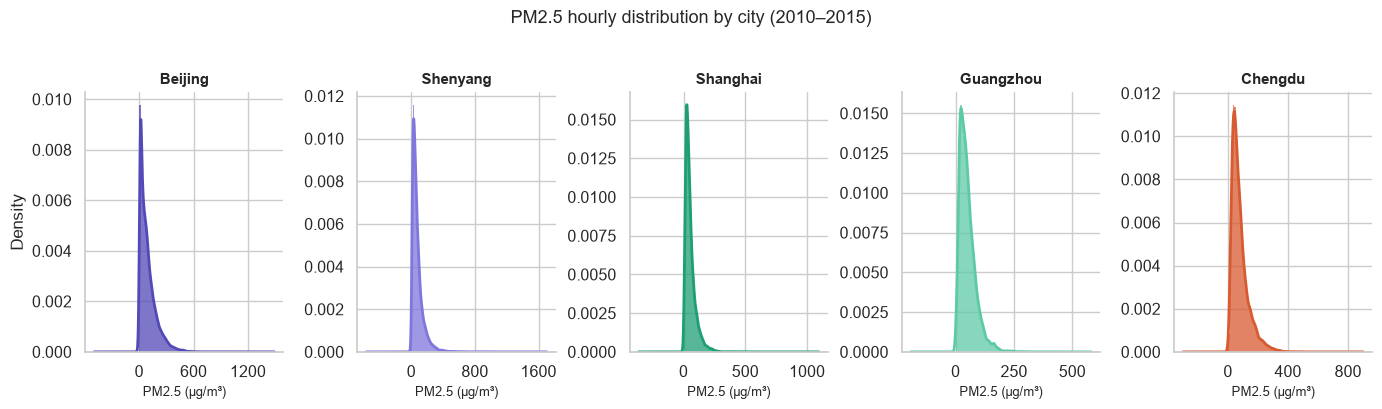

  PM2.5 skewness (positive = right-tailed):
city
Beijing      1.87
Chengdu      1.76
Guangzhou    1.72
Shanghai     2.60
Shenyang     3.56
  → Heavy right tails confirm sporadic extreme pollution events (smog episodes).

══ 2.3  Annual PM2.5 trend (2010–2015) ──────────────────────────────────


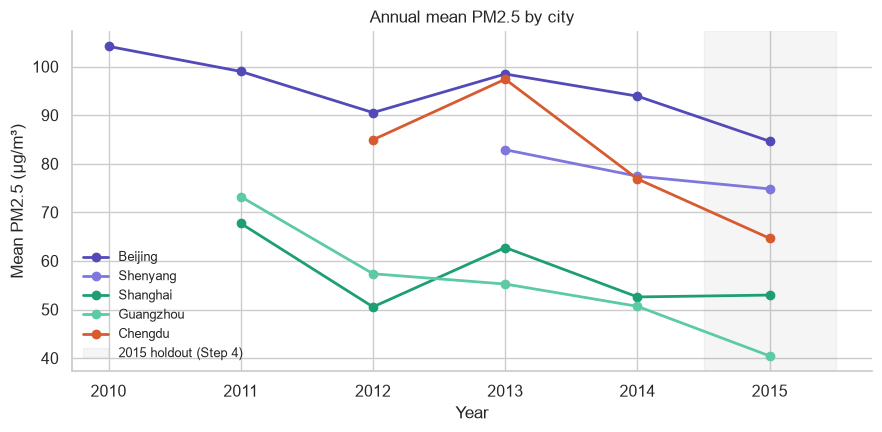

  Grey band = 2015 test set. Inspect visually for structural breaks
  relative to the 2010–2014 training distribution (Kira's guidance).

══ 2.4  Seasonal (monthly) PM2.5 pattern ────────────────────────────────


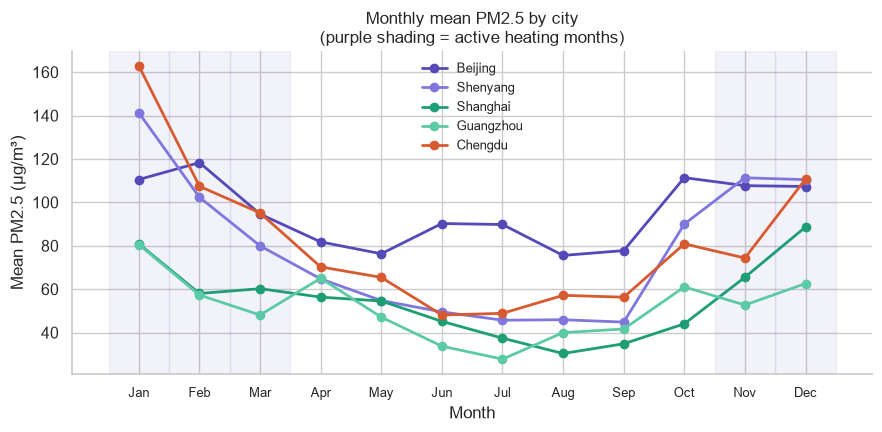

  Beijing    — heating ON: 107.6 µg/m³ | heating OFF: 86.3 µg/m³ | raw lift: +21.3 µg/m³
  Shenyang   — heating ON: 109.3 µg/m³ | heating OFF: 56.5 µg/m³ | raw lift: +52.8 µg/m³
  (Unadjusted for weather confounders — Oliver's causal block handles this.)

══ 2.5  PM2.5 by heating regime ─────────────────────────────────────────


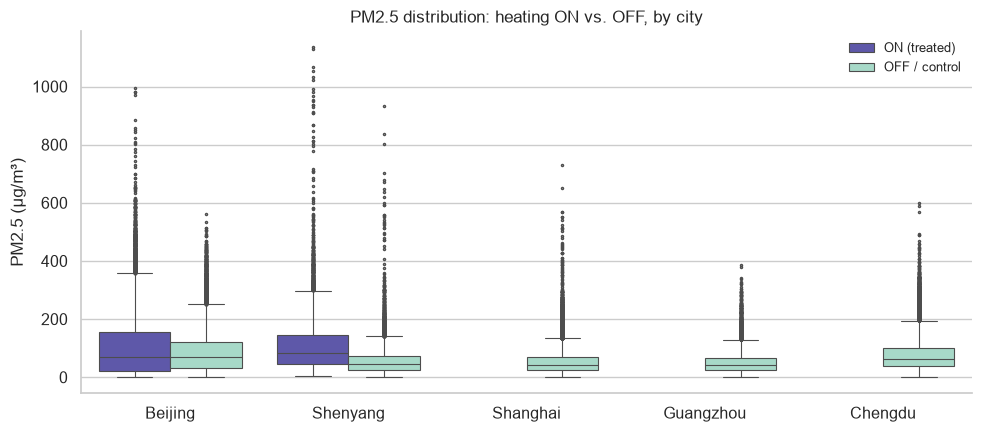


══ 2.6  Correlation heatmap ──────────────────────────────────────────────


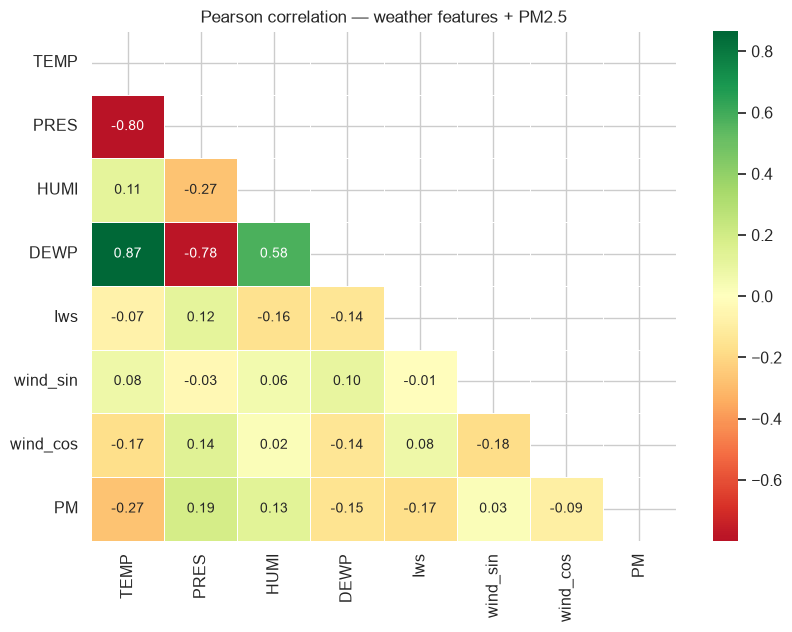

  Key pairings to note for the DAG (Oliver's Step 3):
    TEMP   ↔ PM : r = -0.274  ↓ negative
    PRES   ↔ PM : r = +0.186  ↑ positive
    HUMI   ↔ PM : r = +0.130  ↑ positive
    DEWP   ↔ PM : r = -0.154  ↓ negative
    Iws    ↔ PM : r = -0.170  ↓ negative
    wind_sin ↔ PM : r = +0.026  ↑ positive
    wind_cos ↔ PM : r = -0.093  ↓ negative

══ 2.7  StandardScaler ───────────────────────────────────────────────────
  Post-scaling statistics on training set (2010–2014):
  (mean should be ≈ 0, std should be ≈ 1 — Kira's clustering requirement)


,TEMP_sc,PRES_sc,HUMI_sc,DEWP_sc,Iws_sc,wind_sin_sc,wind_cos_sc
mean,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


  ✓ Scale validation PASSED

  Scaler means (fitted on 2010–2014):
    TEMP  : 15.7454
    PRES  : 1013.6355
    HUMI  : 65.6913
    DEWP  : 8.3103
    Iws   : 22.7994
    wind_sin: 0.0635
    wind_cos: 0.0798
  Scaler stds:
    TEMP  : 11.2622
    PRES  : 10.1084
    HUMI  : 23.1555
    DEWP  : 13.2105
    Iws   : 48.3818
    wind_sin: 0.6434
    wind_cos: 0.6416

══ 2.8  Feature distributions (raw vs. scaled) ──────────────────────────


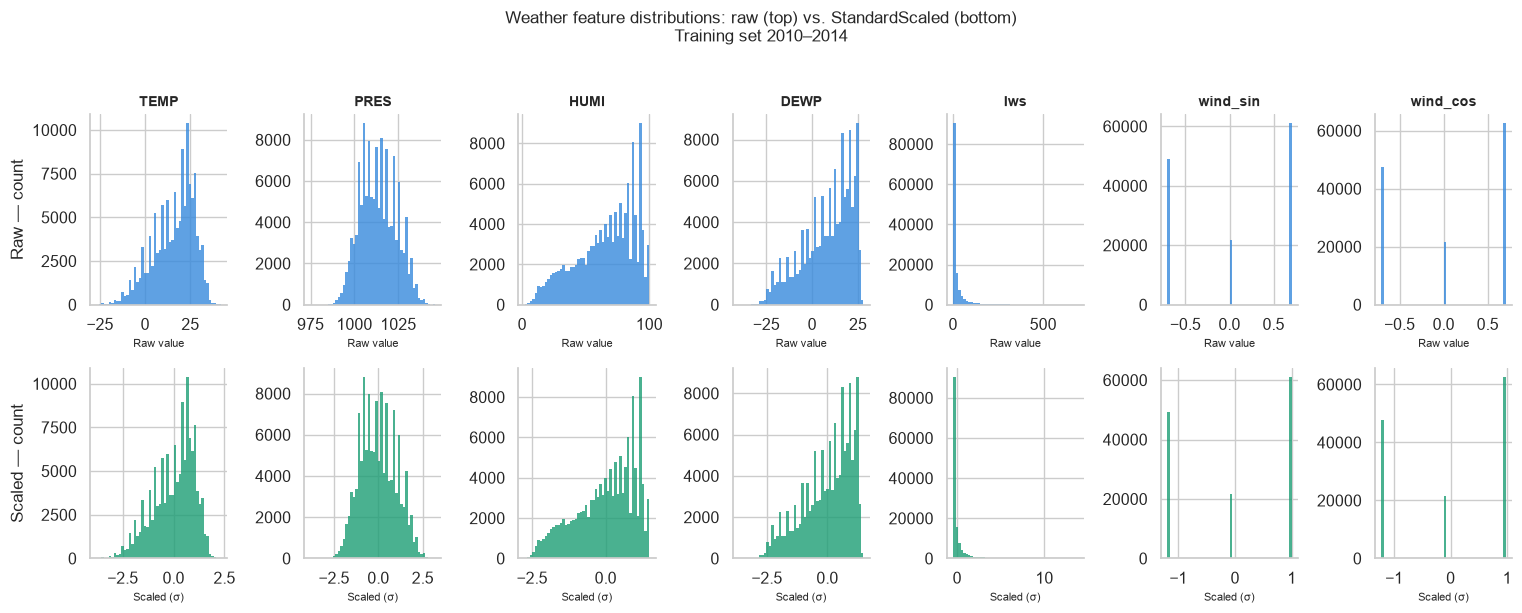


══ 2.9  Diurnal PM2.5 pattern (hour of day) ─────────────────────────────


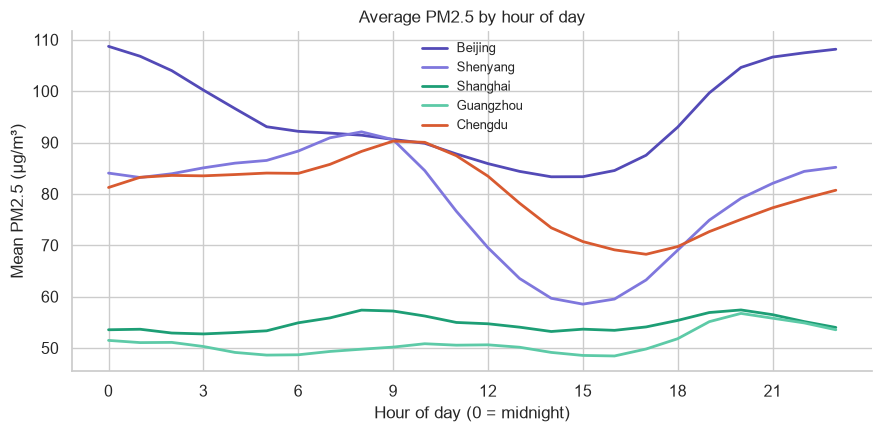


══ 2.10  Mean PM2.5: city × heating regime ──────────────────────────────


Mean PM2.5  Median PM2.5    Obs
city      heating_regime                                 
Beijing   0                     86.3          68.3  29650
          1                    107.6          71.0  20852
Chengdu   0                     80.1          64.0  30133
Guangzhou 0                     51.1          43.0  33501
Shanghai  0                     54.8          42.3  34902
Shenyang  0                     56.5          44.7  15279
          1                    109.3          84.3  10802


══ 2.11  Multicollinearity (VIF) among weather features ─────────────────


,feature,VIF
1,TEMP,48.13
2,PRES,3.21
3,HUMI,17.75
4,DEWP,69.75
5,Iws,1.04
6,wind_sin,1.06
7,wind_cos,1.08


  Rule of thumb: VIF > 5–10 indicates problematic collinearity.
  → High TEMP–DEWP VIF (if present) flags a redundant confounder pair
    to address in Oliver's DAG (Step 3).

══ 2.12  Weather feature skewness (training set) ────────────────────────


,skew
TEMP,-0.63
PRES,0.14
HUMI,-0.56
DEWP,-0.69
Iws,4.58
wind_sin,-0.18
wind_cos,-0.22


  |skew| > 1 suggests a log/sqrt transform may help linear models (Step 3 OLS).
  wind_sin/wind_cos are circular encodings of cbwd; they are intentionally kept as paired features.

══ 2.13  PM2.5 autocorrelation (ACF, first 48 lags) ─────────────────────


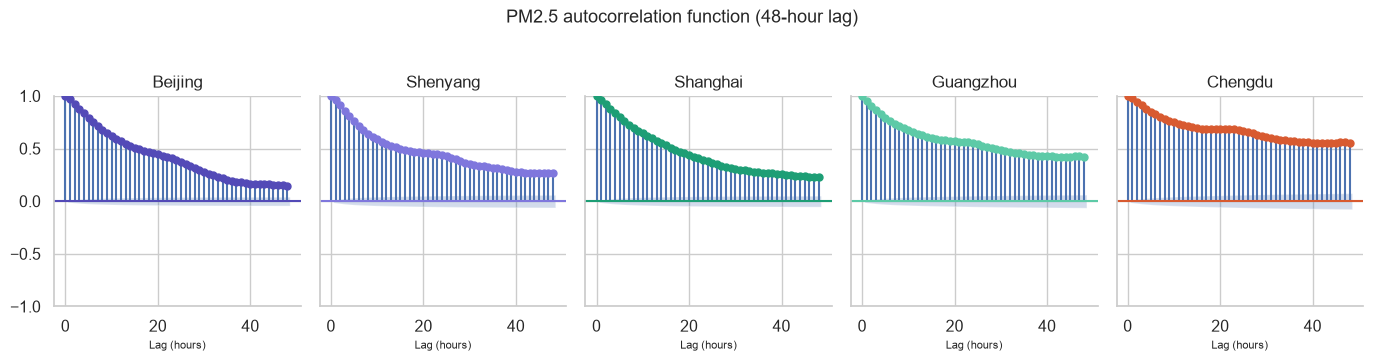

  Strong, slowly-decaying autocorrelation confirms temporal dependence,
  motivating (a) clustered SEs in Step 3 and (b) the lag-1 baseline in Step 4.

══ 2.14  Heating-regime balance (observation counts) ────────────────────


heating_regime,Control (OFF),Treated (ON),Total,Treated %
city,,,,
Beijing,29650,20852,50502,41.3
Chengdu,30133,0,30133,0.0
Guangzhou,33501,0,33501,0.0
Shanghai,34902,0,34902,0.0
Shenyang,15279,10802,26081,41.4



✓ Step 2 complete.
  df_clean now contains scaled feature columns (TEMP_sc, PRES_sc, ...).
  Pass `scaler` to Oliver's Step 5 (K-Means) for inverse-transform reporting.


In [6]:
# =============================================================================
# STEP 2 — Exploratory Data Analysis
# Owner: Danish
# Requires: df_clean from Step 1
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ── Plot aesthetics ───────────────────────────────────────────────────────────
CITY_COLORS = {
    "Beijing":   "#534AB7",   # purple  — northern heating zone
    "Shenyang":  "#7F77DD",   # purple light
    "Shanghai":  "#1D9E75",   # teal    — southern, no mandate
    "Guangzhou": "#5DCAA7",   # teal light
    "Chengdu":   "#D85A30",   # coral
}
CITIES      = list(CITY_COLORS.keys())
FEATURES    = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "wind_sin", "wind_cos"]
FIG_W       = 14

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


# =============================================================================
# 2.1  BASIC DATASET OVERVIEW
# =============================================================================
print("══ 2.1  Dataset overview ════════════════════════════════════════════════")
print(f"  Shape   : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Cities  : {CITIES}")
print(f"  Years   : {df_clean['year'].min()} – {df_clean['year'].max()}")
print(f"\n── Observations per city ────────────────────────────────────────────────")
display(df_clean.groupby("city", observed=True).size().rename("hours").to_frame())

print("\n── PM2.5 summary by city (µg/m³) ───────────────────────────────────────")
display(
    df_clean.groupby("city", observed=True)["PM"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(1)
)


# =============================================================================
# 2.2  PM2.5 DISTRIBUTION — histograms + KDE per city
# =============================================================================
print("\n══ 2.2  PM2.5 distributions ─────────────────────────────────────────────")

fig, axes = plt.subplots(1, 5, figsize=(FIG_W, 4), sharey=False)
for ax, city in zip(axes, CITIES):
    data = df_clean.loc[df_clean["city"] == city, "PM"]
    ax.hist(data, bins=60, color=CITY_COLORS[city], alpha=0.75,
            density=True, edgecolor="none")
    data.plot.kde(ax=ax, color=CITY_COLORS[city], lw=2)
    ax.set_title(city, fontsize=11, fontweight="bold")
    ax.set_xlabel("PM2.5 (µg/m³)", fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
    ax.set_ylabel("Density" if city == "Beijing" else "")

fig.suptitle("PM2.5 hourly distribution by city (2010–2015)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Right-skew note
skews = df_clean.groupby("city", observed=True)["PM"].skew().round(2)
print("  PM2.5 skewness (positive = right-tailed):")
print(skews.to_string())
print("  → Heavy right tails confirm sporadic extreme pollution events (smog episodes).")


# =============================================================================
# 2.3  ANNUAL MEAN PM2.5 TREND — line chart per city
# =============================================================================
print("\n══ 2.3  Annual PM2.5 trend (2010–2015) ──────────────────────────────────")

annual = (df_clean.groupby(["city", "year"], observed=True)["PM"]
          .mean().reset_index().rename(columns={"PM": "PM_mean"}))

fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = annual[annual["city"] == city]
    ax.plot(d["year"], d["PM_mean"], marker="o", lw=2,
            color=CITY_COLORS[city], label=city)

ax.axvspan(2014.5, 2015.5, alpha=0.08, color="gray",
           label="2015 holdout (Step 4)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Annual mean PM2.5 by city")
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print("  Grey band = 2015 test set. Inspect visually for structural breaks")
print("  relative to the 2010–2014 training distribution (Kira's guidance).")


# =============================================================================
# 2.4  SEASONAL PM2.5 PATTERN — monthly mean, all cities overlaid
# =============================================================================
print("\n══ 2.4  Seasonal (monthly) PM2.5 pattern ────────────────────────────────")

monthly = (df_clean.groupby(["city", "month"], observed=True)["PM"]
           .mean().reset_index().rename(columns={"PM": "PM_mean"}))

fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = monthly[monthly["city"] == city]
    ax.plot(d["month"], d["PM_mean"], marker="o", lw=2,
            color=CITY_COLORS[city], label=city)

# Shade the active heating months
for m in [1, 2, 3, 11, 12]:
    ax.axvspan(m - 0.5, m + 0.5, alpha=0.07, color="#534AB7")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=9)
ax.set_xlabel("Month")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Monthly mean PM2.5 by city\n(purple shading = active heating months)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# Heating-regime lift: average PM inside vs. outside heating months, northern cities only
for city in ["Beijing", "Shenyang"]:
    on  = df_clean.loc[(df_clean["city"] == city) & (df_clean["heating_regime"] == 1), "PM"].mean()
    off = df_clean.loc[(df_clean["city"] == city) & (df_clean["heating_regime"] == 0), "PM"].mean()
    print(f"  {city:10s} — heating ON: {on:.1f} µg/m³ | heating OFF: {off:.1f} µg/m³"
          f" | raw lift: +{on - off:.1f} µg/m³")
print("  (Unadjusted for weather confounders — Oliver's causal block handles this.)")


# =============================================================================
# 2.5  HEATING-REGIME BOXPLOT — treatment vs. control, per city
# =============================================================================
print("\n══ 2.5  PM2.5 by heating regime ─────────────────────────────────────────")

df_clean["Heating regime"] = df_clean["heating_regime"].map({1: "ON (treated)", 0: "OFF / control"})

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(
    data=df_clean, x="city", y="PM",
    hue="Heating regime",
    palette={"ON (treated)": "#534AB7", "OFF / control": "#9FE1CB"},
    order=CITIES, fliersize=1.5, linewidth=0.8, ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("PM2.5 distribution: heating ON vs. OFF, by city")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

df_clean.drop(columns=["Heating regime"], inplace=True)   # tidy up helper column


# =============================================================================
# 2.6  CORRELATION HEATMAP — weather features + PM
# =============================================================================
print("\n══ 2.6  Correlation heatmap ──────────────────────────────────────────────")

corr_cols = FEATURES + ["PM"]
corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle is redundant
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.4,
    annot_kws={"size": 10}, ax=ax
)
ax.set_title("Pearson correlation — weather features + PM2.5")
plt.tight_layout()
plt.show()

print("  Key pairings to note for the DAG (Oliver's Step 3):")
for feat in FEATURES:
    r = corr.loc[feat, "PM"]
    direction = "↑ positive" if r > 0 else "↓ negative"
    print(f"    {feat:6s} ↔ PM : r = {r:+.3f}  {direction}")


# =============================================================================
# 2.7  STANDARDSCALER — fit on training years (2010–2014), apply to full panel
# =============================================================================
# IMPORTANT: the scaler is fitted ONLY on the training split (2010–2014) to
# prevent any 2015 test-set statistics from leaking into the scaling parameters.
# This is consistent with the chronological split in Step 4.
print("\n══ 2.7  StandardScaler ───────────────────────────────────────────────────")

train_mask = df_clean["year"] <= 2014

scaler = StandardScaler()
scaler.fit(df_clean.loc[train_mask, FEATURES])

# Scaled columns (suffixed _sc) for use in clustering (Step 5 — Oliver)
# and optionally in the Random Forest (Step 4 — tree-based models are
# scale-invariant, but scaled features are required for K-Means).
scaled_values = scaler.transform(df_clean[FEATURES])
for i, feat in enumerate(FEATURES):
    df_clean[f"{feat}_sc"] = scaled_values[:, i]

# Validation: means ≈ 0, stds ≈ 1 on the training subset
train_scaled = df_clean.loc[train_mask, [f"{f}_sc" for f in FEATURES]]
print("  Post-scaling statistics on training set (2010–2014):")
print("  (mean should be ≈ 0, std should be ≈ 1 — Kira's clustering requirement)")
display(train_scaled.agg(["mean", "std"]).round(4))

assert (train_scaled.mean().abs() < 1e-8).all(), "Scaler mean check failed"
assert (train_scaled.std()  - 1).abs().lt(1e-4).all(), "Scaler std check failed"
print("  ✓ Scale validation PASSED")

# Scaler parameters for documentation / reproducibility
print("\n  Scaler means (fitted on 2010–2014):")
for feat, mu in zip(FEATURES, scaler.mean_):
    print(f"    {feat:6s}: {mu:.4f}")
print("  Scaler stds:")
for feat, sd in zip(FEATURES, scaler.scale_):
    print(f"    {feat:6s}: {sd:.4f}")


# =============================================================================
# 2.8  FEATURE DISTRIBUTIONS — raw vs. scaled, training set
# =============================================================================
print("\n══ 2.8  Feature distributions (raw vs. scaled) ──────────────────────────")

fig, axes = plt.subplots(2, len(FEATURES), figsize=(max(FIG_W, 2.2 * len(FEATURES)), 6))
for col_idx, feat in enumerate(FEATURES):
    # Raw
    ax_raw = axes[0, col_idx]
    df_clean.loc[train_mask, feat].hist(bins=50, ax=ax_raw,
                                        color="#378ADD", alpha=0.8, edgecolor="none")
    ax_raw.set_title(feat, fontsize=10, fontweight="bold")
    ax_raw.set_ylabel("Count" if col_idx == 0 else "")
    ax_raw.set_xlabel("Raw value", fontsize=8)

    # Scaled
    ax_sc = axes[1, col_idx]
    df_clean.loc[train_mask, f"{feat}_sc"].hist(bins=50, ax=ax_sc,
                                                 color="#1D9E75", alpha=0.8, edgecolor="none")
    ax_sc.set_ylabel("Count" if col_idx == 0 else "")
    ax_sc.set_xlabel("Scaled (σ)", fontsize=8)

axes[0, 0].set_ylabel("Raw — count")
axes[1, 0].set_ylabel("Scaled — count")
fig.suptitle("Weather feature distributions: raw (top) vs. StandardScaled (bottom)\n"
             "Training set 2010–2014", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


# =============================================================================
# 2.9  DIURNAL PATTERN — average PM2.5 by hour of day
# =============================================================================
print("\n══ 2.9  Diurnal PM2.5 pattern (hour of day) ─────────────────────────────")

diurnal = (df_clean.groupby(["city", "hour"], observed=True)["PM"]
           .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = diurnal[diurnal["city"] == city]
    ax.plot(d["hour"], d["PM"], lw=2, color=CITY_COLORS[city], label=city)

ax.set_xlabel("Hour of day (0 = midnight)")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Average PM2.5 by hour of day")
ax.set_xticks(range(0, 24, 3))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


# =============================================================================
# 2.10  SUMMARY TABLE — mean PM2.5 by city × heating regime
# =============================================================================
print("\n══ 2.10  Mean PM2.5: city × heating regime ──────────────────────────────")

summary = (df_clean.groupby(["city", "heating_regime"], observed=True)["PM"]
           .agg(["mean", "median", "count"])
           .round(1)
           .rename(columns={"mean": "Mean PM2.5", "median": "Median PM2.5", "count": "Obs"}))
display(summary)

# ── Carry-forward objects ─────────────────────────────────────────────────────
# The following objects are produced here and consumed downstream:
#
#   df_clean   — master panel, now includes *_sc scaled feature columns
#   scaler     — fitted StandardScaler (pass to Step 5 for K-Means)
#   FEATURES   — list of raw weather feature names
#   CITY_COLORS — consistent palette for all subsequent plots
#

# =============================================================================
# 2.11  MULTICOLLINEARITY CHECK — VIF among weather features
# =============================================================================
print("\n══ 2.11  Multicollinearity (VIF) among weather features ─────────────────")

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df_clean.loc[train_mask, FEATURES])
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
display(vif_data[vif_data["feature"] != "const"].round(2))
print("  Rule of thumb: VIF > 5–10 indicates problematic collinearity.")
print("  → High TEMP–DEWP VIF (if present) flags a redundant confounder pair")
print("    to address in Oliver's DAG (Step 3).")


# =============================================================================
# 2.12  SKEWNESS OF WEATHER FEATURES — raw, training set
# =============================================================================
print("\n══ 2.12  Weather feature skewness (training set) ────────────────────────")

feat_skew = df_clean.loc[train_mask, FEATURES].skew().round(2)
display(feat_skew.to_frame("skew"))
print("  |skew| > 1 suggests a log/sqrt transform may help linear models (Step 3 OLS).")
print("  wind_sin/wind_cos are circular encodings of cbwd; they are intentionally kept as paired features.")


# =============================================================================
# 2.13  AUTOCORRELATION OF PM2.5 — ACF per city (first 48 hours)
# =============================================================================
print("\n══ 2.13  PM2.5 autocorrelation (ACF, first 48 lags) ─────────────────────")

from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 5, figsize=(FIG_W, 3.5), sharey=True)
for ax, city in zip(axes, CITIES):
    series = df_clean.loc[df_clean["city"] == city].sort_values(
        ["year", "month", "day", "hour"]
    )["PM"]
    plot_acf(series, lags=48, ax=ax, color=CITY_COLORS[city], title=city)
    ax.set_xlabel("Lag (hours)", fontsize=8)

fig.suptitle("PM2.5 autocorrelation function (48-hour lag)", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

print("  Strong, slowly-decaying autocorrelation confirms temporal dependence,")
print("  motivating (a) clustered SEs in Step 3 and (b) the lag-1 baseline in Step 4.")


# =============================================================================
# 2.14  TREATMENT BALANCE TABLE — heating_regime counts by city
# =============================================================================
print("\n══ 2.14  Heating-regime balance (observation counts) ────────────────────")

balance = (
    df_clean.groupby(["city", "heating_regime"], observed=True)
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Control (OFF)", 1: "Treated (ON)"})
)
balance["Total"] = balance.sum(axis=1)
balance["Treated %"] = (balance["Treated (ON)"] / balance["Total"] * 100).round(1)
display(balance)

print("\n✓ Step 2 complete.")
print("  df_clean now contains scaled feature columns (TEMP_sc, PRES_sc, ...).")
print("  Pass `scaler` to Oliver's Step 5 (K-Means) for inverse-transform reporting.")

══ 4.1  Feature engineering and chronological split ─────────────────
  Tuning-fit years observed : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]
  Validation years observed : [np.int64(2014)]
  Final train years observed: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
  Test years observed       : [np.int64(2015)]
  Tuning fit set (2010–2013): 87,822 rows
  Validation set (2014)     : 43,778 rows
  Final train (2010–2014)   : 131,600 rows
  Final test (2015)         : 43,399 rows
  Number of model features  : 57
  ✓ 2015 remains untouched until final evaluation.

══ 4.1b  2015 structural anomaly check ──────────────────────────────
  KS test — PM2.5 distribution, train vs 2015 test (per city):
    Beijing   : KS=0.090, p=0.0000  [SHIFT (p<0.05)]
    Shenyang  : KS=0.058, p=0.0000  [SHIFT (p<0.05)]
    Shanghai  : KS=0.032, p=0.0000  [SHIFT (p<0.05)]
    Guangzhou : KS=0.210, p=0.0000  [SHIFT (p<0.05)]
    Chengdu   : KS=0.166, p=0.0

,train_mean,test_2015_mean,pct_diff
TEMP,15.754,16.346,3.8
PRES,1013.631,1013.794,0.0
HUMI,65.686,67.892,3.4
DEWP,8.317,9.484,14.0
Iws,22.803,19.705,-13.6
wind_sin,0.063,0.017,-72.6
wind_cos,0.080,0.064,-19.2


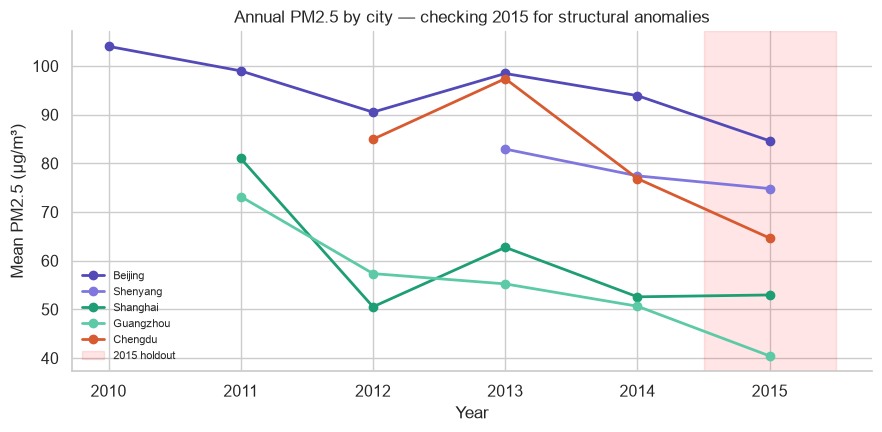


  → 5/5 cities show a statistically significant PM distribution shift in 2015.
  → Treat the 2015 test as a difficult chronological holdout, not an IID random split.

══ 4.1c  2015 anomaly magnitude screen ──────────────────────────────


,city,feature,train_2010_2014_mean,test_2015_mean,z_vs_train_years,flag
4,Beijing,DEWP,1.761,3.381,4.384,EXTREME
0,Beijing,PM,97.194,84.630,-2.430,EXTREME
32,Chengdu,PM,86.416,64.650,-2.104,EXTREME
38,Chengdu,wind_sin,-0.142,-0.162,-9.550,EXTREME
13,Shenyang,Iws,21.213,22.017,3.136,EXTREME
3,Beijing,HUMI,54.246,56.147,1.034,within range
5,Beijing,Iws,23.996,20.472,-0.930,within range
2,Beijing,PRES,1016.440,1016.558,0.184,within range
1,Beijing,TEMP,12.410,13.593,1.429,within range
7,Beijing,wind_cos,0.063,0.066,0.100,within range


  → Extreme city-feature deviations flagged: 5
  → If many 2015 extremes are flagged, report 2015 as an out-of-distribution holdout.

══ 4.2  Baselines: Lag persistence and OLS ──────────────────────────
  Lag-1 persistence RMSE : 13.053
  Lag-24 persistence RMSE: 63.462
  OLS engineered RMSE    : 12.222
  Ridge engineered RMSE  : 12.220  (alpha=336)

══ 4.3  Random Forest tuning using 2014 validation ──────────────────
  Candidate 1: validation RMSE=13.387 | {'n_estimators': 250, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Candidate 2: validation RMSE=13.218 | {'n_estimators': 250, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Candidate 3: validation RMSE=12.850 | {'n_estimators': 250, 'max_depth': 25, 'min_samples_leaf': 3, 'max_features': 0.6}
  Candidate 4: validation RMSE=12.787 | {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.6}
  Candidate 5: validation RMSE=12.970 | {'n_estimators': 300, 'max_depth': 

,candidate,n_estimators,max_depth,min_samples_leaf,max_features,valid_2014_RMSE
0,4,300,NaN,10,0.6,12.787
1,3,250,25.0,3,0.6,12.850
2,5,300,18.0,10,1.0,12.970
3,2,250,18.0,5,sqrt,13.218
4,1,250,12.0,5,sqrt,13.387


  Selected RF params from 2014 validation: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.6}

  Final RF 2015 RMSE: 12.822

══ 4.4  Delta-PM models: predicting change from lag-1 ───────────────
  Delta RF candidate 1: validation RMSE=12.735 | {'n_estimators': 250, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Delta RF candidate 2: validation RMSE=12.610 | {'n_estimators': 250, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Delta RF candidate 3: validation RMSE=12.537 | {'n_estimators': 250, 'max_depth': 25, 'min_samples_leaf': 3, 'max_features': 0.6}
  Delta RF candidate 4: validation RMSE=12.503 | {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.6}
  Delta RF candidate 5: validation RMSE=12.561 | {'n_estimators': 300, 'max_depth': 18, 'min_samples_leaf': 10, 'max_features': 1.0}


In [ ]:
# =============================================================================
# STEP 4 — Improved Supervised Learning: RF vs OLS vs Lag Baselines
# Owner: Danish
# Requires: df_clean from Step 1/2 (with wind features and heating_regime)
# =============================================================================

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ks_2samp

# =============================================================================
# 4.1  FEATURE ENGINEERING WITHOUT 2015 LEAKAGE
# =============================================================================
print("══ 4.1  Feature engineering and chronological split ─────────────────")

# Work on a copy so Step 1/2 outputs remain unchanged.
df_model = df_clean.copy()

# Sort before any lag/rolling features. Lags are calculated within city only.
df_model = df_model.sort_values(["city", "year", "month", "day", "hour"]).reset_index(drop=True)

# Defensive checks for columns created in Step 1.
required_cols = [
    "city", "season", "year", "month", "day", "hour", "PM",
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "wind_sin", "wind_cos", "wind_dir_missing", "heating_regime",
]
missing_cols = [c for c in required_cols if c not in df_model.columns]
assert not missing_cols, f"Missing required columns from Step 1/2: {missing_cols}"

# Multiple PM lags. These are legitimate because they use only past PM values.
LAG_HOURS = [1, 2, 3, 6, 12, 24]
g = df_model.groupby("city", observed=True)["PM"]
for lag in LAG_HOURS:
    df_model[f"PM_lag{lag}"] = g.shift(lag)

# Rolling summaries based only on past values. shift(1) prevents current-hour leakage.
ROLL_WINDOWS = [3, 6, 12, 24]
for window in ROLL_WINDOWS:
    df_model[f"PM_roll{window}"] = (
        g.transform(lambda s, w=window: s.shift(1).rolling(window=w, min_periods=w).mean())
    )

# PM trend / momentum features. These use only already-lagged PM values, so they do
# not leak the current target. They help models learn whether pollution is rising or falling.
df_model["PM_diff1"] = df_model["PM_lag1"] - df_model["PM_lag2"]
df_model["PM_diff3"] = df_model["PM_lag1"] - df_model["PM_lag3"]
df_model["PM_diff6"] = df_model["PM_lag1"] - df_model["PM_lag6"]
df_model["PM_diff24"] = df_model["PM_lag1"] - df_model["PM_lag24"]

# Lagged weather and wind conditions. These are safe because each value is shifted
# within city before prediction. The short lag set keeps the extension defensible and
# avoids adding dozens of arbitrary features after seeing 2015 results.
WEATHER_LAG_BASE = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "wind_sin", "wind_cos"]
WEATHER_LAG_HOURS = [1, 3, 6]
for col in WEATHER_LAG_BASE:
    cg = df_model.groupby("city", observed=True)[col]
    for lag in WEATHER_LAG_HOURS:
        df_model[f"{col}_lag{lag}"] = cg.shift(lag)

# Cyclic temporal features. This avoids treating hour 23 and hour 0 as far apart.
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)
df_model["month_sin"] = np.sin(2 * np.pi * (df_model["month"] - 1) / 12)
df_model["month_cos"] = np.cos(2 * np.pi * (df_model["month"] - 1) / 12)

# Wind-direction interactions: direction matters more when wind speed is non-zero.
df_model["Iws_x_wind_sin"] = df_model["Iws"] * df_model["wind_sin"]
df_model["Iws_x_wind_cos"] = df_model["Iws"] * df_model["wind_cos"]

LAG_FEATURES = [f"PM_lag{lag}" for lag in LAG_HOURS]
ROLL_FEATURES = [f"PM_roll{window}" for window in ROLL_WINDOWS]
PM_TREND_FEATURES = ["PM_diff1", "PM_diff3", "PM_diff6", "PM_diff24"]
WEATHER_FEATURES = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "wind_sin", "wind_cos", "wind_dir_missing",
    "Iws_x_wind_sin", "Iws_x_wind_cos",
]
WEATHER_LAG_FEATURES = [
    f"{col}_lag{lag}" for col in WEATHER_LAG_BASE for lag in WEATHER_LAG_HOURS
]
TIME_FEATURES = ["hour_sin", "hour_cos", "month_sin", "month_cos", "heating_regime"]
BASE_NUMERIC_FEATURES = (
    LAG_FEATURES + ROLL_FEATURES + PM_TREND_FEATURES +
    WEATHER_FEATURES + WEATHER_LAG_FEATURES + TIME_FEATURES
)
TARGET = "PM"

# Drop rows where lag/rolling construction creates missing values. This mainly removes
# the first 24 hours per city, not arbitrary test-year observations.
df_model = df_model.dropna(subset=BASE_NUMERIC_FEATURES + [TARGET]).reset_index(drop=True)

# Add city and season fixed-effect dummies for both OLS and RF. This is a fairer
# comparison because both models receive the same city/season information.
df_enc = pd.get_dummies(df_model, columns=["city", "season"], drop_first=True)
DUMMY_FEATURES = sorted([c for c in df_enc.columns if c.startswith("city_") or c.startswith("season_")])
MODEL_FEATURES = BASE_NUMERIC_FEATURES + DUMMY_FEATURES

# Chronological split design:
# - 2010–2013: fitting during RF hyperparameter tuning
# - 2014: validation for choosing RF hyperparameters
# - 2010–2014: final training after tuning
# - 2015: final untouched test set
train_tune_df = df_enc.loc[df_enc["year"] <= 2013].copy()
valid_df      = df_enc.loc[df_enc["year"] == 2014].copy()
train_df      = df_enc.loc[df_enc["year"] <= 2014].copy()
test_df       = df_enc.loc[df_enc["year"] == 2015].copy()

# Keep chronological order after splitting.
sort_cols = ["year", "month", "day", "hour"]
train_tune_df = train_tune_df.sort_values(sort_cols).reset_index(drop=True)
valid_df      = valid_df.sort_values(sort_cols).reset_index(drop=True)
train_df      = train_df.sort_values(sort_cols).reset_index(drop=True)
test_df       = test_df.sort_values(sort_cols).reset_index(drop=True)

EXPECTED_TRAIN_TUNE_YEARS = {2010, 2011, 2012, 2013}
EXPECTED_VALID_YEARS = {2014}
EXPECTED_TRAIN_YEARS = {2010, 2011, 2012, 2013, 2014}
EXPECTED_TEST_YEARS = {2015}

def observed_years(frame):
    return set(frame["year"].dropna().astype(int).unique())

print(f"  Tuning-fit years observed : {sorted(observed_years(train_tune_df))}")
print(f"  Validation years observed : {sorted(observed_years(valid_df))}")
print(f"  Final train years observed: {sorted(observed_years(train_df))}")
print(f"  Test years observed       : {sorted(observed_years(test_df))}")

assert observed_years(train_tune_df).issubset(EXPECTED_TRAIN_TUNE_YEARS)
assert observed_years(valid_df) == EXPECTED_VALID_YEARS
assert observed_years(train_df).issubset(EXPECTED_TRAIN_YEARS)
assert observed_years(test_df) == EXPECTED_TEST_YEARS
assert train_df["year"].max() < test_df["year"].min(), "Temporal leakage: train overlaps test."

X_tune, y_tune = train_tune_df[MODEL_FEATURES], train_tune_df[TARGET]
X_valid, y_valid = valid_df[MODEL_FEATURES], valid_df[TARGET]
X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET]
X_test, y_test = test_df[MODEL_FEATURES], test_df[TARGET]

print(f"  Tuning fit set (2010–2013): {len(train_tune_df):,} rows")
print(f"  Validation set (2014)     : {len(valid_df):,} rows")
print(f"  Final train (2010–2014)   : {len(train_df):,} rows")
print(f"  Final test (2015)         : {len(test_df):,} rows")
print(f"  Number of model features  : {len(MODEL_FEATURES)}")
print("  ✓ 2015 remains untouched until final evaluation.")


# =============================================================================
# 4.1b  STRUCTURAL-BREAK CHECK — 2015 vs 2010–2014
# =============================================================================
print("\n══ 4.1b  2015 structural anomaly check ──────────────────────────────")

# Use the non-dummied model frame for human-readable city labels.
train_plain = df_model.loc[df_model["year"] <= 2014].copy()
test_plain = df_model.loc[df_model["year"] == 2015].copy()

print("  KS test — PM2.5 distribution, train vs 2015 test (per city):")
ks_results = []
for city in CITIES:
    train_pm = train_plain.loc[train_plain["city"] == city, "PM"]
    test_pm  = test_plain.loc[test_plain["city"] == city, "PM"]
    stat, pval = ks_2samp(train_pm, test_pm)
    flag = "SHIFT (p<0.05)" if pval < 0.05 else "ok"
    ks_results.append({"city": city, "KS_stat": stat, "p_value": pval, "flag": flag})
    print(f"    {city:10s}: KS={stat:.3f}, p={pval:.4f}  [{flag}]")
ks_df = pd.DataFrame(ks_results)

BASE_WEATHER_FOR_SHIFT = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "wind_sin", "wind_cos"]
struct_check = pd.DataFrame({
    "train_mean": train_plain[BASE_WEATHER_FOR_SHIFT].mean(),
    "test_2015_mean": test_plain[BASE_WEATHER_FOR_SHIFT].mean(),
})
denominator = struct_check["train_mean"].replace(0, np.nan)
struct_check["pct_diff"] = ((struct_check["test_2015_mean"] - struct_check["train_mean"]) / denominator * 100).round(1)
print("\n  Mean comparison — weather features, train vs 2015:")
display(struct_check.round(3))

annual_check = df_model.groupby(["city", "year"], observed=True)["PM"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = annual_check[annual_check["city"] == city]
    ax.plot(d["year"], d["PM"], marker="o", lw=2, color=CITY_COLORS[city], label=city)
ax.axvspan(2014.5, 2015.5, alpha=0.1, color="red", label="2015 holdout")
ax.set_xlabel("Year"); ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Annual PM2.5 by city — checking 2015 for structural anomalies")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

n_shift_cities = int((ks_df["p_value"] < 0.05).sum())
print(f"\n  → {n_shift_cities}/{len(CITIES)} cities show a statistically significant PM distribution shift in 2015.")
print("  → Treat the 2015 test as a difficult chronological holdout, not an IID random split.")


# =============================================================================
# 4.1c  2015 ANOMALY MAGNITUDE SCREEN
# =============================================================================
print("\n══ 4.1c  2015 anomaly magnitude screen ──────────────────────────────")

ANOMALY_FEATURES = ["PM"] + BASE_WEATHER_FOR_SHIFT
annual_feature_means = df_model.groupby(["city", "year"], observed=True)[ANOMALY_FEATURES].mean().reset_index()

anomaly_rows = []
for city in CITIES:
    city_annual = annual_feature_means.loc[annual_feature_means["city"] == city]
    train_annual = city_annual.loc[city_annual["year"] <= 2014]
    test_annual = city_annual.loc[city_annual["year"] == 2015]
    if test_annual.empty:
        continue
    for feature in ANOMALY_FEATURES:
        train_vals = train_annual[feature].dropna()
        test_val = float(test_annual[feature].iloc[0])
        train_mean = float(train_vals.mean())
        train_std = float(train_vals.std(ddof=1))
        z_score = np.nan if train_std == 0 or np.isnan(train_std) else (test_val - train_mean) / train_std
        flag = "EXTREME" if pd.notna(z_score) and abs(z_score) >= 2.0 else "within range"
        anomaly_rows.append({
            "city": city,
            "feature": feature,
            "train_2010_2014_mean": train_mean,
            "test_2015_mean": test_val,
            "z_vs_train_years": z_score,
            "flag": flag,
        })

anomaly_df = pd.DataFrame(anomaly_rows)
display(anomaly_df.sort_values(["flag", "city", "feature"]).round(3))
n_extreme = int((anomaly_df["flag"] == "EXTREME").sum())
print(f"  → Extreme city-feature deviations flagged: {n_extreme}")
print("  → If many 2015 extremes are flagged, report 2015 as an out-of-distribution holdout.")


# =============================================================================
# 4.2  BASELINE MODELS
# =============================================================================
print("\n══ 4.2  Baselines: Lag persistence and OLS ──────────────────────────")

def metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

# Naive persistence baselines.
lag1_pred = test_df["PM_lag1"].to_numpy()
lag24_pred = test_df["PM_lag24"].to_numpy()
lag1_metrics = metrics(y_test, lag1_pred)
lag24_metrics = metrics(y_test, lag24_pred)

# OLS on the engineered feature set.
ols = LinearRegression()
ols.fit(X_train, y_train)
ols_pred = ols.predict(X_test)
ols_metrics = metrics(y_test, ols_pred)

# Ridge can be useful when many lag/rolling features are strongly correlated.
ridge = RidgeCV(alphas=np.logspace(-3, 4, 20))
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_metrics = metrics(y_test, ridge_pred)

print(f"  Lag-1 persistence RMSE : {lag1_metrics['RMSE']:.3f}")
print(f"  Lag-24 persistence RMSE: {lag24_metrics['RMSE']:.3f}")
print(f"  OLS engineered RMSE    : {ols_metrics['RMSE']:.3f}")
print(f"  Ridge engineered RMSE  : {ridge_metrics['RMSE']:.3f}  (alpha={ridge.alpha_:.4g})")


# =============================================================================
# 4.3  RANDOM FOREST TUNING ON 2014 VALIDATION ONLY
# =============================================================================
print("\n══ 4.3  Random Forest tuning using 2014 validation ──────────────────")

# This grid is intentionally modest to avoid tuning until the 2015 result looks good.
# We choose parameters on 2014 only, then refit once on 2010–2014 and evaluate once on 2015.
RF_PARAM_GRID = [
    {"n_estimators": 250, "max_depth": 12,   "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": 18,   "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": 25,   "min_samples_leaf": 3,  "max_features": 0.60},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 10, "max_features": 0.60},
    {"n_estimators": 300, "max_depth": 18,   "min_samples_leaf": 10, "max_features": 1.00},
]

rf_tuning_rows = []
for i, params in enumerate(RF_PARAM_GRID, start=1):
    rf_candidate = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf_candidate.fit(X_tune, y_tune)
    valid_pred = rf_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
    rf_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  Candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

rf_tuning_df = pd.DataFrame(rf_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_rf_params = {
    k: rf_tuning_df.loc[0, k]
    for k in ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
}
# pandas may convert integer-like values to numpy scalar; cast where needed.
best_rf_params["n_estimators"] = int(best_rf_params["n_estimators"])
best_rf_params["min_samples_leaf"] = int(best_rf_params["min_samples_leaf"])
if pd.notna(best_rf_params["max_depth"]):
    best_rf_params["max_depth"] = int(best_rf_params["max_depth"])
else:
    best_rf_params["max_depth"] = None

print("\n  RF validation results:")
display(rf_tuning_df.round(3))
print(f"  Selected RF params from 2014 validation: {best_rf_params}")

# Final RF: refit on all pre-2015 data, evaluate once on 2015.
rf = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = metrics(y_test, rf_pred)
print(f"\n  Final RF 2015 RMSE: {rf_metrics['RMSE']:.3f}")


# =============================================================================
# 4.4  DELTA-PM MODELS — predict deviation from lag-1 persistence
# =============================================================================
print("\n══ 4.4  Delta-PM models: predicting change from lag-1 ───────────────")

# Alternative target: PM_t - PM_(t-1). Final prediction is PM_lag1 + predicted change.
# This tests whether models can explain deviations beyond naive persistence.
y_tune_delta = y_tune - train_tune_df["PM_lag1"]
y_valid_delta = y_valid - valid_df["PM_lag1"]
y_train_delta = y_train - train_df["PM_lag1"]

ols_delta = LinearRegression()
ols_delta.fit(X_train, y_train_delta)
ols_delta_pred = test_df["PM_lag1"].to_numpy() + ols_delta.predict(X_test)
ols_delta_metrics = metrics(y_test, ols_delta_pred)

# Tune delta RF on 2014 as well. Use the same small parameter grid.
rf_delta_tuning_rows = []
for i, params in enumerate(RF_PARAM_GRID, start=1):
    rf_delta_candidate = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf_delta_candidate.fit(X_tune, y_tune_delta)
    valid_delta_pm_pred = valid_df["PM_lag1"].to_numpy() + rf_delta_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_delta_pm_pred))
    rf_delta_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  Delta RF candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

rf_delta_tuning_df = pd.DataFrame(rf_delta_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_rf_delta_params = {
    k: rf_delta_tuning_df.loc[0, k]
    for k in ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
}
best_rf_delta_params["n_estimators"] = int(best_rf_delta_params["n_estimators"])
best_rf_delta_params["min_samples_leaf"] = int(best_rf_delta_params["min_samples_leaf"])
if pd.notna(best_rf_delta_params["max_depth"]):
    best_rf_delta_params["max_depth"] = int(best_rf_delta_params["max_depth"])
else:
    best_rf_delta_params["max_depth"] = None

rf_delta = RandomForestRegressor(**best_rf_delta_params, random_state=42, n_jobs=-1)
rf_delta.fit(X_train, y_train_delta)
rf_delta_pred = test_df["PM_lag1"].to_numpy() + rf_delta.predict(X_test)
rf_delta_metrics = metrics(y_test, rf_delta_pred)

print("\n  Delta RF validation results:")
display(rf_delta_tuning_df.round(3))
print(f"  Selected delta-RF params: {best_rf_delta_params}")
print(f"  OLS delta 2015 RMSE: {ols_delta_metrics['RMSE']:.3f}")
print(f"  RF delta 2015 RMSE : {rf_delta_metrics['RMSE']:.3f}")


# =============================================================================
# 4.4b  HISTOGRAM GRADIENT BOOSTING — validation-tuned ML alternative
# =============================================================================
print("\n══ 4.4b  HistGradientBoosting tuning using 2014 validation ───────────")

print("  Purpose: test a stronger tabular ML model without tuning on 2015.")
print("  This is an exploratory ML alternative; the original proposal target still refers to Random Forest.")

HGB_PARAM_GRID = [
    {"learning_rate": 0.03, "max_iter": 400, "max_leaf_nodes": 15, "min_samples_leaf": 30, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 31, "min_samples_leaf": 20, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 31, "min_samples_leaf": 30, "l2_regularization": 0.1},
    {"learning_rate": 0.08, "max_iter": 250, "max_leaf_nodes": 31, "min_samples_leaf": 30, "l2_regularization": 0.1},
    {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 63, "min_samples_leaf": 50, "l2_regularization": 0.1},
]

hgb_tuning_rows = []
for i, params in enumerate(HGB_PARAM_GRID, start=1):
    hgb_candidate = HistGradientBoostingRegressor(
        **params, random_state=42, early_stopping=False
    )
    hgb_candidate.fit(X_tune, y_tune)
    valid_pred = hgb_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
    hgb_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  HGB candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

hgb_tuning_df = pd.DataFrame(hgb_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_hgb_params = {
    k: hgb_tuning_df.loc[0, k]
    for k in ["learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]
}
best_hgb_params["max_iter"] = int(best_hgb_params["max_iter"])
best_hgb_params["max_leaf_nodes"] = int(best_hgb_params["max_leaf_nodes"])
best_hgb_params["min_samples_leaf"] = int(best_hgb_params["min_samples_leaf"])

hgb = HistGradientBoostingRegressor(
    **best_hgb_params, random_state=42, early_stopping=False
)
hgb.fit(X_train, y_train)
hgb_pred = hgb.predict(X_test)
hgb_metrics = metrics(y_test, hgb_pred)

# Delta version of HGB.
hgb_delta_tuning_rows = []
for i, params in enumerate(HGB_PARAM_GRID, start=1):
    hgb_delta_candidate = HistGradientBoostingRegressor(
        **params, random_state=42, early_stopping=False
    )
    hgb_delta_candidate.fit(X_tune, y_tune_delta)
    valid_delta_pm_pred = valid_df["PM_lag1"].to_numpy() + hgb_delta_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_delta_pm_pred))
    hgb_delta_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  HGB delta candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

hgb_delta_tuning_df = pd.DataFrame(hgb_delta_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_hgb_delta_params = {
    k: hgb_delta_tuning_df.loc[0, k]
    for k in ["learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]
}
best_hgb_delta_params["max_iter"] = int(best_hgb_delta_params["max_iter"])
best_hgb_delta_params["max_leaf_nodes"] = int(best_hgb_delta_params["max_leaf_nodes"])
best_hgb_delta_params["min_samples_leaf"] = int(best_hgb_delta_params["min_samples_leaf"])

hgb_delta = HistGradientBoostingRegressor(
    **best_hgb_delta_params, random_state=42, early_stopping=False
)
hgb_delta.fit(X_train, y_train_delta)
hgb_delta_pred = test_df["PM_lag1"].to_numpy() + hgb_delta.predict(X_test)
hgb_delta_metrics = metrics(y_test, hgb_delta_pred)

print("\n  HGB validation results:")
display(hgb_tuning_df.round(3))
print(f"  Selected HGB params: {best_hgb_params}")
print(f"  HGB 2015 RMSE      : {hgb_metrics['RMSE']:.3f}")

print("\n  HGB delta validation results:")
display(hgb_delta_tuning_df.round(3))
print(f"  Selected HGB-delta params: {best_hgb_delta_params}")
print(f"  HGB delta 2015 RMSE: {hgb_delta_metrics['RMSE']:.3f}")


# =============================================================================
# 4.5  FINAL MODEL COMPARISON — 2015 HOLDOUT
# =============================================================================
print("\n══ 4.5  Final model comparison on untouched 2015 holdout ────────────")

predictions = {
    "Lag-1 persistence": lag1_pred,
    "Lag-24 persistence": lag24_pred,
    "OLS engineered": ols_pred,
    "Ridge engineered": ridge_pred,
    "RF engineered": rf_pred,
    "OLS delta": ols_delta_pred,
    "RF delta": rf_delta_pred,
    "HGB engineered": hgb_pred,
    "HGB delta": hgb_delta_pred,
}

results = []
for model_name, pred in predictions.items():
    m = metrics(y_test, pred)
    results.append({"Model": model_name, **m})
results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

best_model = results.loc[0, "Model"]
best_rmse = float(results.loc[0, "RMSE"])
lag1_rmse = lag1_metrics["RMSE"]
ols_rmse = ols_metrics["RMSE"]
rf_rmse = rf_metrics["RMSE"]
rf_delta_rmse = rf_delta_metrics["RMSE"]
hgb_rmse = hgb_metrics["RMSE"]
hgb_delta_rmse = hgb_delta_metrics["RMSE"]

# Proposal target: RF success requires at least 15% lower RMSE than Lag-1 and OLS.
for baseline_name, baseline_rmse in [("Lag-1 persistence", lag1_rmse), ("OLS engineered", ols_rmse)]:
    results[f"RMSE reduction vs {baseline_name} (%)"] = ((baseline_rmse - results["RMSE"]) / baseline_rmse * 100).round(1)

display(results.round(3))

for ml_name, ml_model_rmse in [
    ("RF engineered", rf_rmse), ("RF delta", rf_delta_rmse),
    ("HGB engineered", hgb_rmse), ("HGB delta", hgb_delta_rmse),
]:
    print(f"\n  {ml_name}:")
    for baseline_name, baseline_rmse in [("Lag-1", lag1_rmse), ("OLS engineered", ols_rmse)]:
        reduction = (baseline_rmse - ml_model_rmse) / baseline_rmse * 100
        status = "✓ PASSED" if reduction >= 15 else "✗ NOT MET"
        print(f"    vs {baseline_name:15s}: {reduction:+.1f}% RMSE reduction (target ≥15%) — {status}")

print("\n  Interpretation note:")
print("    HGB is included as an exploratory stronger tabular ML model. Do not claim it was the")
print("    original RF benchmark unless you explicitly present it as an additional robustness model.")

print(f"\n  Best 2015 model by RMSE: {best_model} (RMSE={best_rmse:.3f})")
print("  Note: because hyperparameters were selected on 2014, this 2015 result remains a fair final holdout test.")


# =============================================================================
# 4.6  CITY-MONTH BLOCK BOOTSTRAP FOR FINAL RMSE UNCERTAINTY
# =============================================================================
print("\n══ 4.6  City-month block bootstrap for RMSE uncertainty ─────────────")

print("  Bootstrap design:")
print("    • Unit resampled: city × month blocks from the 2015 holdout set.")
print("    • This penalizes spatial autocorrelation within cities and temporal autocorrelation within months.")
print("    • We recompute RMSE and proposal target success probabilities over 1,000 block draws.")

# Recreate human-readable city labels for test_df from dummy columns.
# Easier: use test_plain, but it must align with test_df after the same filtering/sorting.
eval_plain = df_model.loc[df_model["year"] == 2015].sort_values(sort_cols).reset_index(drop=True)
assert len(eval_plain) == len(test_df), "Alignment issue between encoded and plain test frames."

# Some cities may be tied only through dummies after drop_first, so use eval_plain for block labels.
eval_df = eval_plain[["city", "year", "month", "day", "hour", "PM", "PM_lag1"]].copy()
for model_name, pred in predictions.items():
    safe_name = model_name.replace(" ", "_").replace("-", "")
    eval_df[f"pred_{safe_name}"] = pred
    eval_df[f"sqerr_{safe_name}"] = (eval_df["PM"] - pred) ** 2

eval_df["city_month_block"] = (
    eval_df["city"].astype(str) + "_" + eval_df["year"].astype(str) + "_" +
    eval_df["month"].astype(str).str.zfill(2)
)

agg_dict = {"n": ("PM", "size"), "city": ("city", "first"), "month": ("month", "first")}
model_safe_names = []
for model_name in predictions:
    safe_name = model_name.replace(" ", "_").replace("-", "")
    model_safe_names.append((model_name, safe_name))
    agg_dict[f"{safe_name}_sse"] = (f"sqerr_{safe_name}", "sum")

block_summary = eval_df.groupby("city_month_block", observed=True).agg(**agg_dict).reset_index()

N_BOOT = 1000
rng = np.random.default_rng(42)
n_blocks = len(block_summary)
n_arr = block_summary["n"].to_numpy(dtype=float)
sse_cols = [f"{safe_name}_sse" for _, safe_name in model_safe_names]
sse_arr = block_summary[sse_cols].to_numpy(dtype=float)

boot_rows = []
for _ in range(N_BOOT):
    draw = rng.integers(0, n_blocks, size=n_blocks)
    n_total = n_arr[draw].sum()
    sse_total = sse_arr[draw].sum(axis=0)
    rmse_vals = np.sqrt(sse_total / n_total)
    row = {f"{model_name}_RMSE": rmse for (model_name, _), rmse in zip(model_safe_names, rmse_vals)}
    row["RF_engineered_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["RF engineered_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["RF_engineered_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["RF engineered_RMSE"]) / row["OLS engineered_RMSE"] * 100
    row["RF_delta_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["RF delta_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["RF_delta_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["RF delta_RMSE"]) / row["OLS engineered_RMSE"] * 100
    row["HGB_engineered_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["HGB engineered_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["HGB_engineered_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["HGB engineered_RMSE"]) / row["OLS engineered_RMSE"] * 100
    row["HGB_delta_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["HGB delta_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["HGB_delta_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["HGB delta_RMSE"]) / row["OLS engineered_RMSE"] * 100
    boot_rows.append(row)

bootstrap_df = pd.DataFrame(boot_rows)

point_estimates = {}
for model_name, pred in predictions.items():
    point_estimates[f"{model_name}_RMSE"] = metrics(y_test, pred)["RMSE"]
point_estimates["RF_engineered_vs_Lag1_reduction_pct"] = (lag1_rmse - rf_rmse) / lag1_rmse * 100
point_estimates["RF_engineered_vs_OLS_reduction_pct"] = (ols_rmse - rf_rmse) / ols_rmse * 100
point_estimates["RF_delta_vs_Lag1_reduction_pct"] = (lag1_rmse - rf_delta_rmse) / lag1_rmse * 100
point_estimates["RF_delta_vs_OLS_reduction_pct"] = (ols_rmse - rf_delta_rmse) / ols_rmse * 100
point_estimates["HGB_engineered_vs_Lag1_reduction_pct"] = (lag1_rmse - hgb_rmse) / lag1_rmse * 100
point_estimates["HGB_engineered_vs_OLS_reduction_pct"] = (ols_rmse - hgb_rmse) / ols_rmse * 100
point_estimates["HGB_delta_vs_Lag1_reduction_pct"] = (lag1_rmse - hgb_delta_rmse) / lag1_rmse * 100
point_estimates["HGB_delta_vs_OLS_reduction_pct"] = (ols_rmse - hgb_delta_rmse) / ols_rmse * 100

bootstrap_summary = bootstrap_df.quantile([0.025, 0.5, 0.975]).T
bootstrap_summary.columns = ["ci_2.5%", "bootstrap_median", "ci_97.5%"]
bootstrap_summary.insert(0, "point_estimate", pd.Series(point_estimates))
display(bootstrap_summary.round(3))

prob_success = pd.Series({
    "P(RF engineered beats Lag-1 by ≥15%)": float((bootstrap_df["RF_engineered_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(RF engineered beats OLS by ≥15%)": float((bootstrap_df["RF_engineered_vs_OLS_reduction_pct"] >= 15).mean()),
    "P(RF delta beats Lag-1 by ≥15%)": float((bootstrap_df["RF_delta_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(RF delta beats OLS by ≥15%)": float((bootstrap_df["RF_delta_vs_OLS_reduction_pct"] >= 15).mean()),
    "P(HGB engineered beats Lag-1 by ≥15%)": float((bootstrap_df["HGB_engineered_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(HGB engineered beats OLS by ≥15%)": float((bootstrap_df["HGB_engineered_vs_OLS_reduction_pct"] >= 15).mean()),
    "P(HGB delta beats Lag-1 by ≥15%)": float((bootstrap_df["HGB_delta_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(HGB delta beats OLS by ≥15%)": float((bootstrap_df["HGB_delta_vs_OLS_reduction_pct"] >= 15).mean()),
})

print("\n  Bootstrap probability of meeting the proposal success threshold:")
for label, value in prob_success.items():
    print(f"    {label}: {value:.3f}")


# =============================================================================
# 4.7  OPTIONAL OLS TWO-WAY CLUSTERED STANDARD ERRORS — CITY AND MONTH
# =============================================================================
print("\n══ 4.7  OLS two-way clustered standard errors ───────────────────────")

try:
    import statsmodels.api as sm

    # To avoid an oversized clustered-SE table with many dummy variables, report
    # the main engineered OLS specification but keep the full feature matrix.
    X_train_sm = sm.add_constant(X_train.astype(float), has_constant="add")
    y_train_sm = y_train.astype(float)
    ols_sm = sm.OLS(y_train_sm, X_train_sm).fit()

    # Two-way clustering: city and calendar month.
    train_plain_for_groups = df_model.loc[df_model["year"] <= 2014].sort_values(sort_cols).reset_index(drop=True)
    assert len(train_plain_for_groups) == len(train_df), "Alignment issue for clustered-SE groups."
    groups_2way = np.column_stack([
        train_plain_for_groups["city"].astype("category").cat.codes.to_numpy(),
        train_plain_for_groups["month"].astype(int).to_numpy(),
    ])

    ols_clustered = ols_sm.get_robustcov_results(cov_type="cluster", groups=groups_2way)
    clustered_ols_table = pd.DataFrame({
        "coef": ols_clustered.params,
        "std_err_city_month_clustered": ols_clustered.bse,
        "t": ols_clustered.tvalues,
        "p_value": ols_clustered.pvalues,
    }, index=X_train_sm.columns)

    # Display the most substantively important coefficients first.
    priority_rows = ["const", "PM_lag1", "PM_lag2", "PM_lag24", "PM_roll24", "PM_diff24", "TEMP", "TEMP_lag1", "HUMI", "Iws", "Iws_lag1", "heating_regime"]
    priority_rows = [r for r in priority_rows if r in clustered_ols_table.index]
    display(clustered_ols_table.loc[priority_rows].round(4))
    print("  ✓ Two-way clustered OLS standard errors computed by city and month.")
    print("  Note: only five city clusters exist, so coefficient inference remains cautious;")
    print("  the city-month block bootstrap above is the main RMSE uncertainty check.")

except Exception as exc:
    clustered_ols_table = None
    print("  statsmodels clustered-SE section could not be run in this environment.")
    print(f"  Reason: {type(exc).__name__}: {exc}")
    print("  The city-month block bootstrap above remains the main out-of-sample uncertainty check.")


# =============================================================================
# 4.8  FEATURE IMPORTANCE — RANDOM FOREST
# =============================================================================
print("\n══ 4.8  Feature importance — Random Forest ──────────────────────────")

importances = pd.Series(rf.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)
display(importances.head(20).to_frame("importance").round(4))

fig, ax = plt.subplots(figsize=(8, 5))
importances.head(20).sort_values().plot.barh(ax=ax)
ax.set_xlabel("Importance (impurity-based)")
ax.set_title("Top 20 Random Forest feature importances")
plt.tight_layout()
plt.show()

# =============================================================================
# 4.9  PREDICTED VS ACTUAL — sample week, per city
# =============================================================================
print("\n══ 4.9  Predicted vs actual PM2.5 — sample week by city ─────────────")

# Use the best RF-style prediction for the plot. If delta RF beats engineered RF, use it.
plot_rf_name = "RF delta" if rf_delta_rmse < rf_rmse else "RF engineered"
plot_rf_pred = rf_delta_pred if rf_delta_rmse < rf_rmse else rf_pred

eval_plain["PM_pred_rf_best"] = plot_rf_pred

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=False)
for ax, city in zip(axes, CITIES):
    city_data = eval_plain.loc[(eval_plain["city"] == city) & (eval_plain["month"] == 1)].head(168)
    ax.plot(range(len(city_data)), city_data["PM"], label="Actual", color="black", lw=1.2)
    ax.plot(range(len(city_data)), city_data["PM_pred_rf_best"], label=plot_rf_name,
            color=CITY_COLORS[city], lw=1.2, alpha=0.85)
    ax.set_title(city, fontsize=10, fontweight="bold")
    ax.set_ylabel("PM2.5")
    ax.legend(frameon=False, fontsize=8)
axes[-1].set_xlabel("Hour (first week of Jan 2015)")
fig.suptitle(f"{plot_rf_name}: predicted vs actual PM2.5 — 2015 holdout", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


# =============================================================================
# 4.10  RESIDUAL DIAGNOSTICS
# =============================================================================
print("\n══ 4.10  Residual diagnostics — best RF-style model ─────────────────")

residuals = y_test.to_numpy() - plot_rf_pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(plot_rf_pred, residuals, s=2, alpha=0.2)
axes[0].axhline(0, color="black", lw=1, ls="--")
axes[0].set_xlabel("Predicted PM2.5")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted")
axes[1].hist(residuals, bins=60, edgecolor="none")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.show()

print(f"  Residual mean : {residuals.mean():.3f}")
print(f"  Residual std  : {residuals.std():.3f}")
if n_shift_cities > 0:
    print(f"\n  Note: {n_shift_cities} cities show a 2015 PM distribution shift.")
    print("  If residual bias remains, discuss part of the error as distribution shift rather than pure model failure.")

print("\n✓ Step 4 complete.")
print("  Main objects available: results, rf_tuning_df, rf_delta_tuning_df, hgb_tuning_df, hgb_delta_tuning_df,")
print("  bootstrap_df, bootstrap_summary, ks_df, struct_check, anomaly_df, rf, hgb, ols, ridge, rf_delta, hgb_delta,")
print("  and clustered_ols_table if available.")


In [ ]:
beijing_df=df_model.loc[df_model["city"] == "Beijing"].sort_values(sort_cols).reset_index(drop=True)
feature_df = (
    beijing_df[["precipitation", "HUMI", "TEMP", "DEWP", "Iws", "PRES"]]
    .dropna()
    .rename(
        columns={
            "HUMI": "humidity",
            "TEMP": "temperature",
            "DEWP": "dew_point",
            "Iws": "instant_wind_speed",
            "PRES": "pressure",
        }
    )
    .copy()
)

feature_df.head(), feature_df.shape

(   precipitation  humidity  temperature  dew_point  instant_wind_speed  \
 0            0.0      85.0         -6.0       -8.0               55.43   
 1            0.4      92.0         -6.0       -7.0               58.56   
 2            0.5      85.0         -6.0       -8.0               61.69   
 3            0.5      92.0         -7.0       -8.0               65.71   
 4            0.7      92.0         -7.0       -8.0               68.84   
 
    pressure  
 0    1027.0  
 1    1027.0  
 2    1026.0  
 3    1026.0  
 4    1025.0  ,
 (49998, 6))

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_df)

k_values = range(2, 6)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_features)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

model_selection_df = pd.DataFrame(
    {
        "k": list(k_values),
        "inertia": inertias,
        "silhouette_score": silhouette_scores,
    }
)

best_k = model_selection_df.loc[model_selection_df["silhouette_score"].idxmax(), "k"]
model_selection_df, best_k

(   k        inertia  silhouette_score
 0  2  190791.255847          0.395975
 1  3  157218.366088          0.406161
 2  4  136269.774214          0.341879
 3  5  108675.273584          0.350129,
 np.int64(3))

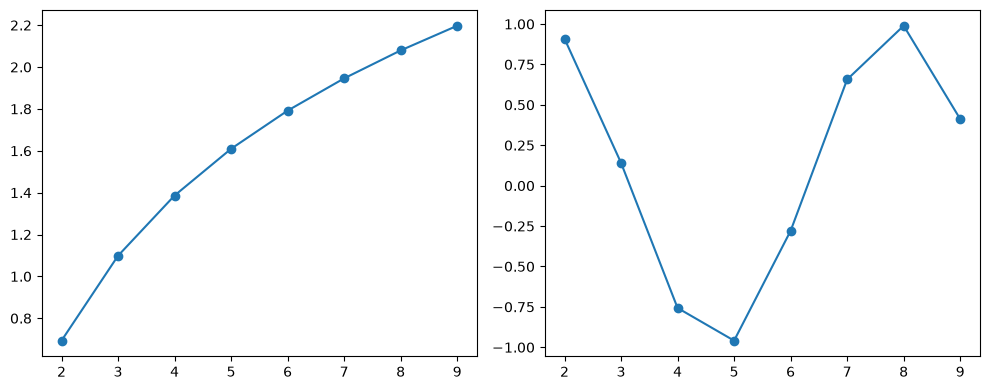

NameError: name 'model_selection_df' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
axes[0].plot(model_selection_df["k"], model_selection_df["inertia"], marker="o", color="tab:blue")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(model_selection_df["k"], model_selection_df["silhouette_score"], marker="o", color="tab:green")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.axvline(best_k, color="tab:red", linestyle="--", alpha=0.7)
    ax.text(best_k + 0.05, ax.get_ylim()[1] * 0.92, f"best k = {best_k}", color="tab:red")

plt.tight_layout()
plt.show()

In [ ]:
# K-means analysis with k=4
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(scaled_features)
centroids_k4 = scaler.inverse_transform(kmeans_k4.cluster_centers_)

centroid_df = pd.DataFrame(centroids_k4, columns=feature_df.columns)
centroid_df.round(2)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
pcs = pca.fit_transform(feature_df[["precipitation", "humidity", "temperature", "dew_point", "instant_wind_speed", "pressure"]])
feature_df['PC1'], feature_df['PC2'] = pcs[:, 0], pcs[:, 1]

sns.scatterplot(data=feature_df, x='PC1', y='PC2', hue='cluster', 
                palette='Set2', alpha=0.5, s=20)
# Add centroids
centroids = feature_df.groupby('cluster')[['PC1', 'PC2']].mean()
plt.scatter(centroids['PC1'], centroids['PC2'], 
            c=centroids.index, s=200, marker='X', edgecolor='black')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

ValueError: Could not interpret value `cluster` for `hue`. An entry with this name does not appear in `data`.

: 